<a href="https://colab.research.google.com/github/nomin-hub/AIFFEL_quest_cr/blob/main/NLP/NLP02/Transformer%EB%A1%9C_%EB%B2%88%EC%97%AD%EA%B8%B0_%EB%A7%8C%EB%93%A4%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transformer로 번역기 만들기 프로젝트 1

### 학습 내용:

2. 내부 모듈 구현하기 :
트랜스포머를 완성하는 데에 필요한 모듈들을 학습합니다.
3. 모듈 조립하기 :
완성한 모듈들을 가지고 트랜스포머 모델을 완성하기.
4. 모델 밖의 조력자들 :
모델 외적인 부분을 정의하고 데이터의 특성이나 학습 과정에 따라 달라지는 부분을 학습합니다.

### 환경 준비

In [ ]:
!mkdir -p ~/work/translator

In [ ]:
# 한영 번역에 필요한 패키지 설치
!pip install torch torchtext sentencepiece sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.3 MB/s eta 0:00:00


In [ ]:
# 1. 나눔 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

# ⚠️ 여기서 런타임 재시작 후 아래 셀 실행!

# 2. 폰트 적용
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

print("✅ 한국어 폰트 설정 완료:", font_name)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import re
import os
import io
import time
import random
import math
import seaborn as sns

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용 디바이스:", device)
print("PyTorch 버전:", torch.__version__)

### 데이터 준비

In [5]:
# 데이터 다운로드 및 압축 해제
%cd ~/work/transformer/data
!wget https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
!gzip -d korean-english-park.train.tar.gz
!tar -xvf korean-english-park.train.tar

[Errno 2] No such file or directory: '/root/work/transformer/data'
/content
--2026-05-14 01:14:15--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-05-14 01:14:16--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [applica

In [6]:
# data 폴더 생성 후 파일 이동
!mkdir -p ~/work/transformer/data
!mv /content/korean-english-park.train.en ~/work/transformer/data/
!mv /content/korean-english-park.train.ko ~/work/transformer/data/

!ls ~/work/transformer/data/

korean-english-park.train.en  korean-english-park.train.ko


In [7]:
# 데이터 미리 보기

In [8]:
with open('/root/work/transformer/data/korean-english-park.train.ko', 'r') as f:
    ko_lines = f.readlines()

with open('/root/work/transformer/data/korean-english-park.train.en', 'r') as f:
    en_lines = f.readlines()

print(f"총 문장 수: {len(ko_lines)}")
print()
print("=== 샘플 5개 ===")
for i in range(5):
    print(f"KO: {ko_lines[i].strip()}")
    print(f"EN: {en_lines[i].strip()}")
    print()

총 문장 수: 94123

=== 샘플 5개 ===
KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
EN: Much of personal computing is about "can you top this?"

KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

KO: 그러나 이것은 또한 책상도 필요로 하지 않는다.
EN: Like all optical mice, But it also doesn't need a desk.

KO: 79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다.
EN: uses gyroscopic sensors to control the cursor movement as you move your wrist, arm, whatever through the air.

KO: 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며, 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다.
EN: Intelligence officials have revealed a spate of foiled plots on ships in Southeast Asia and are warning that a narrow stretch of water carrying almost one third of the world's maritime trade is vulnerable to a terror attack.



In [9]:
# 전처리

In [10]:
def clean_text(text):
    text = text.strip()
    text = re.sub(r"[^\w\s\.\,\!\?\'\"\-]", "", text)  # 특수문자 제거
    text = re.sub(r"\s+", " ", text)  # 연속 공백 제거
    return text

ko_cleaned = [clean_text(line) for line in ko_lines]
en_cleaned = [clean_text(line) for line in en_lines]

# 빈 문장 쌍 제거
pairs = [(ko, en) for ko, en in zip(ko_cleaned, en_cleaned) if ko and en]

print(f"정제 전: {len(ko_lines)}개")
print(f"정제 후: {len(pairs)}개")
print()
print("=== 정제된 샘플 3개 ===")
for ko, en in pairs[:3]:
    print(f"KO: {ko}")
    print(f"EN: {en}")
    print()

정제 전: 94123개
정제 후: 94113개

=== 정제된 샘플 3개 ===
KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
EN: Much of personal computing is about "can you top this?"

KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

KO: 그러나 이것은 또한 책상도 필요로 하지 않는다.
EN: Like all optical mice, But it also doesn't need a desk.



In [11]:
# SentencePiece 토크나이저 학습

In [12]:
import sentencepiece as spm

# 학습용 텍스트 파일 저장
with open('/root/work/transformer/data/ko_temp.txt', 'w') as f:
    f.write('\n'.join([p[0] for p in pairs]))

with open('/root/work/transformer/data/en_temp.txt', 'w') as f:
    f.write('\n'.join([p[1] for p in pairs]))

# 한국어 토크나이저 학습
spm.SentencePieceTrainer.train(
    input='/root/work/transformer/data/ko_temp.txt',
    model_prefix='/root/work/transformer/data/ko_spm',
    vocab_size=8000,
    character_coverage=0.9999,  # 한국어는 높게 설정
    model_type='bpe'
)

# 영어 토크나이저 학습
spm.SentencePieceTrainer.train(
    input='/root/work/transformer/data/en_temp.txt',
    model_prefix='/root/work/transformer/data/en_spm',
    vocab_size=8000,
    character_coverage=0.9995,  # 영어는 약간 낮게
    model_type='bpe'
)

print("토크나이저 학습 완료!")

# 토크나이저 로드
ko_tokenizer = spm.SentencePieceProcessor()
ko_tokenizer.load('/root/work/transformer/data/ko_spm.model')

en_tokenizer = spm.SentencePieceProcessor()
en_tokenizer.load('/root/work/transformer/data/en_spm.model')

# 테스트
sample_ko = pairs[0][0]
sample_en = pairs[0][1]
print(f"\nKO 원문: {sample_ko}")
print(f"KO 토큰: {ko_tokenizer.encode(sample_ko, out_type=str)}")
print(f"\nEN 원문: {sample_en}")
print(f"EN 토큰: {en_tokenizer.encode(sample_en, out_type=str)}")

토크나이저 학습 완료!

KO 원문: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
KO 토큰: ['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분', '은', '▁"', '이', '것', '보다', '▁뛰어', '날', '▁수', '▁있', '느', '냐', '?', '"']

EN 원문: Much of personal computing is about "can you top this?"
EN 토큰: ['▁M', 'uch', '▁of', '▁personal', '▁comput', 'ing', '▁is', '▁about', '▁"', 'can', '▁you', '▁top', '▁this', '?"']


In [13]:
# 특수 토큰 ID 정의
PAD_ID = 0
BOS_ID = 1  # Begin Of Sentence
EOS_ID = 2  # End Of Sentence
MAX_LEN = 128  # 최대 문장 길이

def encode(text, tokenizer, max_len):
    tokens = tokenizer.encode(text)
    tokens = [BOS_ID] + tokens + [EOS_ID]  # 앞뒤에 BOS, EOS 추가
    # max_len 맞게 자르거나 패딩
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    else:
        tokens += [PAD_ID] * (max_len - len(tokens))
    return tokens

from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, pairs, ko_tokenizer, en_tokenizer, max_len):
        self.pairs = pairs
        self.ko_tokenizer = ko_tokenizer
        self.en_tokenizer = en_tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ko, en = self.pairs[idx]
        src = encode(ko, self.ko_tokenizer, self.max_len)
        tgt = encode(en, self.en_tokenizer, self.max_len)
        return (
            torch.tensor(src, dtype=torch.long),
            torch.tensor(tgt, dtype=torch.long)
        )

# 학습/검증 분리 (90% / 10%)
split = int(len(pairs) * 0.9)
train_pairs = pairs[:split]
valid_pairs = pairs[split:]

train_dataset = TranslationDataset(train_pairs, ko_tokenizer, en_tokenizer, MAX_LEN)
valid_dataset = TranslationDataset(valid_pairs, ko_tokenizer, en_tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

print(f"학습 데이터: {len(train_dataset)}개")
print(f"검증 데이터: {len(valid_dataset)}개")
print(f"\n배치 shape 확인:")
src_batch, tgt_batch = next(iter(train_loader))
print(f"src: {src_batch.shape}")  # (64, 128)
print(f"tgt: {tgt_batch.shape}")  # (64, 128)

학습 데이터: 84701개
검증 데이터: 9412개

배치 shape 확인:
src: torch.Size([64, 128])
tgt: torch.Size([64, 128])


### Module 구현

In [14]:
def positional_encoding(pos, d_model):
    # 1. 각도 계산 함수
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)
        # position / 10000^(i/d_model)

    # 2. 한 위치의 각도 벡터 생성
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
        # d_model 차원만큼 각도값 리스트 생성

    # 3. 전체 위치(0~pos)에 대한 테이블 생성
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    # shape: (pos, d_model)

    # 4. 짝수 인덱스 → sin, 홀수 → cos 적용
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table  # shape: (pos, d_model)

print("ok~")

ok~


 코드를 짤 때 문법 오류는 바로 보이지만, shape 오류는 나중에 조립할 때 터진다 하여 모듈 하나 만들 때마다 shape을 바로 확인하기로 했습니다.

In [15]:
# 동작 확인
sample_pe = positional_encoding(128, 512)
print(f"shape: {sample_pe.shape}")
print("Positional Encoding 완료!")

shape: (128, 512)
Positional Encoding 완료!


In [16]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("ok~")

ok~


In [17]:
# 동작 확인
d_model = 512
num_heads = 8

mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

# 가짜 입력 (배치 2, 길이 10, 차원 512)
dummy = torch.zeros(2, 10, d_model)

out, attn = mha(dummy, dummy, dummy)
print(f"입력 shape: {dummy.shape}")
print(f"출력 shape: {out.shape}")       # (2, 10, 512)
print(f"어텐션 shape: {attn.shape}")    # (2, 8, 10, 10)
print("Multi-Head Attention 완료!")

입력 shape: torch.Size([2, 10, 512])
출력 shape: torch.Size([2, 10, 512])
어텐션 shape: torch.Size([2, 8, 10, 10])
Multi-Head Attention 완료!


In [18]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        out = self.w_2(out)

        return out

print("ok~")

ok~


In [19]:
# 동작 확인
d_model = 512
d_ff = 2048  # 보통 d_model의 4배

ffn = PoswiseFeedForwardNet(d_model=d_model, d_ff=d_ff)

dummy = torch.zeros(2, 10, d_model)
out = ffn(dummy)
print(f"입력 shape: {dummy.shape}")
print(f"출력 shape: {out.shape}")   # (2, 10, 512)
print("Feed Forward Network 완료!")

입력 shape: torch.Size([2, 10, 512])
출력 shape: torch.Size([2, 10, 512])
Feed Forward Network 완료!


### Module 조립

In [20]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

print("ok~")

ok~


In [21]:
# 동작 확인
d_model = 512
n_heads = 8
d_ff = 2048
dropout = 0.1

enc_layer = EncoderLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)

dummy = torch.zeros(2, 10, d_model)
out, attn = enc_layer(dummy, mask=None)
print(f"입력 shape: {dummy.shape}")
print(f"출력 shape: {out.shape}")      # (2, 10, 512)
print(f"어텐션 shape: {attn.shape}")   # (2, 8, 10, 10)
print("EncoderLayer 완료!")

입력 shape: torch.Size([2, 10, 512])
출력 shape: torch.Size([2, 10, 512])
어텐션 shape: torch.Size([2, 8, 10, 10])
EncoderLayer 완료!


In [22]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, causality_mask, padding_mask):
        """
        Masked Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, padding_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, causality_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("ok~")

ok~


In [23]:
# 동작 확인
d_model = 512
num_heads = 8
d_ff = 2048
dropout = 0.1

dec_layer = DecoderLayer(d_model=d_model, num_heads=num_heads, d_ff=d_ff, dropout=dropout)

# 가짜 입력
dummy_tgt = torch.zeros(2, 10, d_model)   # 디코더 입력
dummy_enc = torch.zeros(2, 20, d_model)   # 인코더 출력

out, dec_attn, dec_enc_attn = dec_layer(dummy_tgt, dummy_enc, causality_mask=None, padding_mask=None)
print(f"입력 shape: {dummy_tgt.shape}")
print(f"출력 shape: {out.shape}")                # (2, 10, 512)
print(f"self-attn shape: {dec_attn.shape}")      # (2, 8, 10, 10)
print(f"cross-attn shape: {dec_enc_attn.shape}") # (2, 8, 10, 20)
print("DecoderLayer 완료!")

입력 shape: torch.Size([2, 10, 512])
출력 shape: torch.Size([2, 10, 512])
self-attn shape: torch.Size([2, 8, 10, 10])
cross-attn shape: torch.Size([2, 8, 10, 20])
DecoderLayer 완료!


In [24]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("ok~")

ok~


In [25]:
# 동작 확인
n_layers = 6
d_model = 512
n_heads = 8
d_ff = 2048
dropout = 0.1

encoder = Encoder(n_layers=n_layers, d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)

dummy = torch.zeros(2, 10, d_model)
out, enc_attns = encoder(dummy, mask=None)
print(f"입력 shape: {dummy.shape}")
print(f"출력 shape: {out.shape}")             # (2, 10, 512)
print(f"어텐션 레이어 수: {len(enc_attns)}")  # 6
print(f"어텐션 shape: {enc_attns[0].shape}")  # (2, 8, 10, 10)
print("Encoder 완료!")

입력 shape: torch.Size([2, 10, 512])
출력 shape: torch.Size([2, 10, 512])
어텐션 레이어 수: 6
어텐션 shape: torch.Size([2, 8, 10, 10])
Encoder 완료!


In [26]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, causality_mask, padding_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, causality_mask, padding_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("ok~")

ok~


In [27]:
# 동작 확인
n_layers = 6
d_model = 512
n_heads = 8
d_ff = 2048
dropout = 0.1

decoder = Decoder(n_layers=n_layers, d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)

dummy_tgt = torch.zeros(2, 10, d_model)   # 디코더 입력
dummy_enc = torch.zeros(2, 20, d_model)   # 인코더 출력

out, dec_attns, dec_enc_attns = decoder(dummy_tgt, dummy_enc, causality_mask=None, padding_mask=None)
print(f"입력 shape: {dummy_tgt.shape}")
print(f"출력 shape: {out.shape}")                  # (2, 10, 512)
print(f"self-attn 레이어 수: {len(dec_attns)}")    # 6
print(f"cross-attn 레이어 수: {len(dec_enc_attns)}") # 6
print(f"self-attn shape: {dec_attns[0].shape}")    # (2, 8, 10, 10)
print(f"cross-attn shape: {dec_enc_attns[0].shape}") # (2, 8, 10, 20)
print("Decoder 완료!")

입력 shape: torch.Size([2, 10, 512])
출력 shape: torch.Size([2, 10, 512])
self-attn 레이어 수: 6
cross-attn 레이어 수: 6
self-attn shape: torch.Size([2, 8, 10, 10])
cross-attn shape: torch.Size([2, 8, 10, 20])
Decoder 완료!


In [28]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = self.positional_encoding(pos_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)
        pos_encoding[:, 1::2] = torch.cos(position * div_term)
        return pos_encoding.to(device)  # .to(device) 추가 Transformer 클래스 안에서 pos_encoding을 GPU로 올려주기

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, causality_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, causality_mask, dec_mask)

        logits = self.fc(dec_out)

        return logits, enc_attns, dec_attns, dec_enc_attns

print("ok~")

ok~


In [29]:
# 동작 확인
n_layers = 6
d_model = 512
n_heads = 8
d_ff = 2048
dropout = 0.1
src_vocab_size = 8000
tgt_vocab_size = 8000
pos_len = 128

transformer = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=src_vocab_size,
    tgt_vocab_size=tgt_vocab_size,
    pos_len=pos_len,
    dropout=dropout
).to(device)  # ← 추가

# 가짜 입력 GPU로 (배치 2, 길이 10)
enc_in = torch.randint(0, src_vocab_size, (2, 10)).to(device)
dec_in = torch.randint(0, tgt_vocab_size, (2, 10)).to(device)

logits, enc_attns, dec_attns, dec_enc_attns = transformer(
    enc_in, dec_in,
    enc_mask=None, causality_mask=None, dec_mask=None
)
print(f"enc_in shape: {enc_in.shape}")
print(f"dec_in shape: {dec_in.shape}")
print(f"logits shape: {logits.shape}")   # (2, 10, 8000)
print("Transformer 완료!")

enc_in shape: torch.Size([2, 10])
dec_in shape: torch.Size([2, 10])
logits shape: torch.Size([2, 10, 8000])
Transformer 완료!


### 모델 밖의 조력자들

In [30]:
import torch
import numpy as np

def generate_padding_mask(seq):
    mask = (seq == 0).float()
    return mask.unsqueeze(1).unsqueeze(2)

def generate_causality_mask(size):
    """Causal Mask 생성 (Upper triangular matrix)"""
    mask = torch.triu(torch.ones(size, size), diagonal=1)
    return mask

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(tgt)
    seq_len = tgt.shape[-1]
    causal_mask = generate_causality_mask(seq_len)
    batch_size = src.shape[0]
    dec_mask = causal_mask.expand(batch_size, 1, seq_len, seq_len)

    # GPU로 올리기 추가
    enc_mask = enc_mask.to(device)
    dec_enc_mask = dec_enc_mask.to(device)
    dec_mask = dec_mask.to(device)

    return enc_mask, dec_enc_mask, dec_mask

print("ok~")

ok~


In [31]:
# 동작 확인
src = torch.tensor([[1, 2, 3, 0, 0],   # 뒤 2개가 PAD
                    [1, 2, 3, 4, 0]])   # 뒤 1개가 PAD

tgt = torch.tensor([[1, 2, 0, 0, 0],   # 뒤 3개가 PAD
                    [1, 2, 3, 4, 5]])   # PAD 없음

enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

print(f"enc_mask shape: {enc_mask.shape}")         # (2, 1, 1, 5)
print(f"dec_enc_mask shape: {dec_enc_mask.shape}") # (2, 1, 1, 5)
print(f"dec_mask shape: {dec_mask.shape}")         # (2, 1, 5, 5)
print()
print("enc_mask (PAD 위치가 1):")
print(enc_mask.squeeze())
print()
print("dec_mask (미래 위치가 1):")
print(dec_mask[0].squeeze())
print("마스크 생성 완료!")

enc_mask shape: torch.Size([2, 1, 1, 5])
dec_enc_mask shape: torch.Size([2, 1, 1, 5])
dec_mask shape: torch.Size([2, 1, 5, 5])

enc_mask (PAD 위치가 1):
tensor([[0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.]])

dec_mask (미래 위치가 1):
tensor([[0., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1.],
        [0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.]])
마스크 생성 완료!


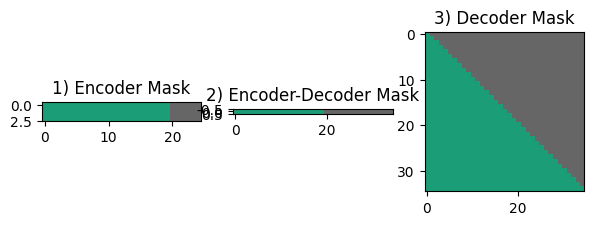

In [32]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15
src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))
sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')
ax1.imshow(enc_mask[:3, 0, 0].cpu().numpy(), cmap='Dark2')   # ← .cpu() 추가
ax2.imshow(dec_enc_mask[0, 0].cpu().numpy(), cmap='Dark2')   # ← .cpu() 추가
ax3.imshow(dec_mask[0, 0].cpu().numpy(), cmap='Dark2')       # ← .cpu() 추가
plt.show()

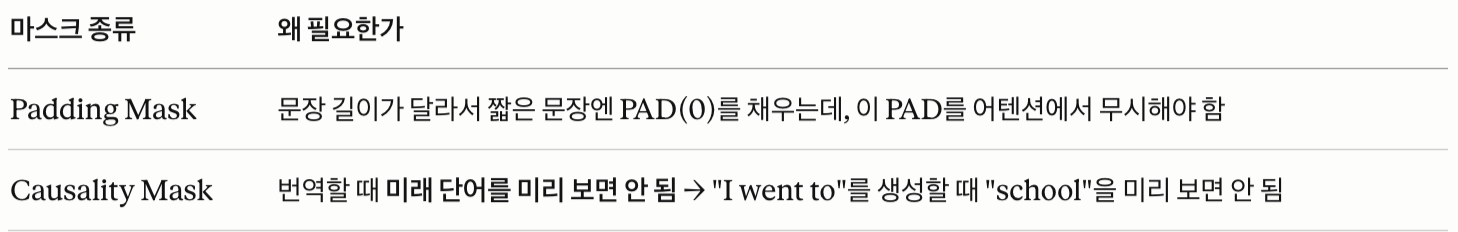

In [33]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=4000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = torch.tensor(step, dtype=torch.float32)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * torch.minimum(arg1, arg2)

model = nn.Linear(10, 10)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9)

print("ok~")

ok~


In [ ]:
# 폰트 재설치
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
# 동작 확인 - LR 스케줄 시각화
temp_optimizer = torch.optim.Adam(
    [torch.zeros(1)], lr=1e-9
)
scheduler = LearningRateScheduler(optimizer=temp_optimizer, d_model=512, warmup_steps=4000)

steps = range(1, 20000)
lrs = []
for step in steps:
    scheduler.last_epoch = step
    lrs.append(scheduler.get_lr()[0])

plt.figure(figsize=(8, 4))
plt.plot(steps, lrs)
plt.axvline(x=4000, color='r', linestyle='--', label='warmup_steps=4000')
plt.title('Learning Rate Schedule')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.show()

print(f"최대 LR: {max(lrs):.6f} (step {lrs.index(max(lrs))+1})")
print("LR 스케줄러 완료!")

### 학습

In [ ]:
# vocab size 변수 정의
SRC_VOCAB_SIZE = ko_tokenizer.get_piece_size()  # 8000
TGT_VOCAB_SIZE = en_tokenizer.get_piece_size()  # 8000

# Transformer 선언 (과제 제공 하이퍼파라미터)
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)

print(f"총 파라미터 수: {sum(p.numel() for p in transformer.parameters()):,}")
print("Transformer 선언 완료!")

In [ ]:
# 2️⃣ LR 스케줄러 + Adam Optimizer 선언 (논문 기준)
import math

class LearningRateScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super(LearningRateScheduler, self).__init__(optimizer, last_epoch)
    def get_lr(self):
        step = max(1, self.last_epoch)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        lr = (self.d_model ** -0.5) * min(arg1, arg2)
        return [lr for _ in self.base_lrs]

# optimizer 먼저 선언
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=1e-9,
    betas=(0.9, 0.98),
    eps=1e-9
)

# 스케줄러 선언
learning_rate = LearningRateScheduler(optimizer, d_model=512)

# optimizer 재선언 (스케줄러 LR 적용)
optimizer = torch.optim.Adam(
    optimizer.param_groups,
    lr=learning_rate.get_lr()[0],
    betas=(0.9, 0.98),
    eps=1e-9
)

print(f"초기 LR: {learning_rate.get_lr()[0]:.10f}")
print("ok~")

In [ ]:
loss_object = torch.nn.CrossEntropyLoss(reduction='none')

def loss_function(real, pred):
    mask = (real != 0)
    loss_ = loss_object(pred, real)

    # Masking 되지 않은 입력의 개수로 Scaling하는 과정
    mask = mask.float()
    loss_ *= mask

    return loss_.sum() / mask.sum()

print("ok~")

In [ ]:
# 동작 확인
dummy_real = torch.tensor([[1, 2, 3, 0, 0],   # 뒤 2개 PAD
                            [1, 2, 3, 4, 5]])   # PAD 없음

dummy_pred = torch.randn(2, 5, 8000)  # (배치, 시퀀스, vocab_size)

# pred는 CrossEntropyLoss 형식에 맞게 변환
loss = loss_function(
    dummy_real.reshape(-1),
    dummy_pred.reshape(-1, 8000)
)

print(f"loss: {loss.item():.4f}")
print("Loss 함수 완료!")

In [ ]:
# Train Step 함수 정의
def train_step(src, tgt, model, optimizer):
    gold = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)

    # 계산된 loss에 대해 역전파(Backpropagation)를 적용해 학습을 진행합니다.
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(
        gold.reshape(-1),                      # ← reshape 추가
        predictions[:, :-1].reshape(-1, TGT_VOCAB_SIZE)  # ← reshape 추가
    )
    loss.backward()
    optimizer.step()
    return loss, enc_attns, dec_attns, dec_enc_attns

print("ok~")

In [ ]:
# 동작 확인
src_batch, tgt_batch = next(iter(train_loader))
src_batch = src_batch.to(device)
tgt_batch = tgt_batch.to(device)

loss, enc_attns, dec_attns, dec_enc_attns = train_step(
    src_batch, tgt_batch, transformer, optimizer
)

print(f"loss: {loss.item():.4f}")
print(f"enc_attns 레이어 수: {len(enc_attns)}")
print(f"dec_attns 레이어 수: {len(dec_attns)}")
print("Train Step 완료!")

In [ ]:
# 전처리 함수
def preprocess_sentence(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"[^\w\s\.\,\!\?\'\"\-]", "", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence

# 번역 생성 함수
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    model.eval()
    with torch.no_grad():
        sentence = preprocess_sentence(sentence)
        tokens = src_tokenizer.encode_as_ids(sentence)
        tokens = [BOS_ID] + tokens + [EOS_ID]
        if len(tokens) < MAX_LEN:
            tokens += [PAD_ID] * (MAX_LEN - len(tokens))
        _input = torch.tensor(tokens).unsqueeze(0).to(device)  # (1, 128)

        ids = []
        output = torch.tensor([[BOS_ID]]).to(device)

        for _ in range(MAX_LEN):
            # output을 MAX_LEN에 맞게 패딩
            output_padded = torch.zeros(1, MAX_LEN, dtype=torch.long).to(device)
            output_padded[0, :output.size(1)] = output[0]

            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output_padded)
            predictions, enc_attns, dec_attns, dec_enc_attns = \
                model(_input, output_padded, enc_mask, dec_enc_mask, dec_mask)

            # output 실제 길이 위치의 예측값 사용
            predicted_id = torch.argmax(
                torch.softmax(predictions[0, output.size(1)-1], dim=-1)
            ).item()

            if tgt_tokenizer.eos_id() == predicted_id:
                break
            ids.append(predicted_id)
            output = torch.cat(
                [output, torch.tensor([[predicted_id]]).to(device)], dim=-1
            )

        pieces = src_tokenizer.encode_as_pieces(sentence)
        result = tgt_tokenizer.decode_ids(ids)
        return pieces, result, enc_attns, dec_attns, dec_enc_attns

print("ok~")

In [ ]:
def evaluate(sentence, model, src_tokenizer, tgt_tokenizer):
    model.eval()
    with torch.no_grad():
        sentence = preprocess_sentence(sentence)
        tokens = src_tokenizer.encode_as_ids(sentence)
        tokens = [BOS_ID] + tokens + [EOS_ID]
        if len(tokens) < MAX_LEN:
            tokens += [PAD_ID] * (MAX_LEN - len(tokens))
        _input = torch.tensor(tokens).unsqueeze(0).to(device)

        ids = []
        output = torch.tensor([[BOS_ID]]).to(device)

        for _ in range(50):  # MAX_LEN → 50으로 제한
            output_padded = torch.zeros(1, MAX_LEN, dtype=torch.long).to(device)
            output_padded[0, :output.size(1)] = output[0]

            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output_padded)
            predictions, enc_attns, dec_attns, dec_enc_attns = \
                model(_input, output_padded, enc_mask, dec_enc_mask, dec_mask)

            predicted_id = torch.argmax(
                torch.softmax(predictions[0, output.size(1)-1], dim=-1)
            ).item()

            if tgt_tokenizer.eos_id() == predicted_id:
                break

            # 같은 단어 3번 이상 반복되면 중단
            if len(ids) >= 3 and ids[-1] == ids[-2] == ids[-3] == predicted_id:
                break

            ids.append(predicted_id)
            output = torch.cat(
                [output, torch.tensor([[predicted_id]]).to(device)], dim=-1
            )

        pieces = src_tokenizer.encode_as_pieces(sentence)
        result = tgt_tokenizer.decode_ids(ids)
        return pieces, result, enc_attns, dec_attns, dec_enc_attns

print("ok~")

In [ ]:
# 학습 루프 (수정)
EPOCHS = 20

test_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    transformer.train()
    total_loss = 0
    start_time = time.time()

    for i, (src_batch, tgt_batch) in enumerate(train_loader):
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        loss, _, _, _ = train_step(src_batch, tgt_batch, transformer, optimizer)
        optimizer.step()           # ← optimizer 먼저
        learning_rate.step()       # ← 스케줄러 나중
        total_loss += loss.item()

        if (i + 1) % 100 == 0:
            print(f"Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"\n✅ Epoch {epoch+1} 완료 | 평균 Loss: {avg_loss:.4f} | 시간: {elapsed:.1f}s")

    # 매 Epoch마다 번역 테스트
    print("\n=== 번역 테스트 ===")
    transformer.eval()
    for i, sent in enumerate(test_sentences, 1):
        _, result, _, _, _ = evaluate(sent, transformer, ko_tokenizer, en_tokenizer)
        print(f"{i}. {sent} → {result}")
    print()

학습 루프는 epoch15까지 돌렸지만 번역 성능이 안 좋아 ... 한 번 점검 후 돌리려고 했으나 GPU사용 한계에 달아서 ... 주말에 다시 돌리고 올릴 예정입니다.